<a href="https://colab.research.google.com/github/thrishaa-112/Advanced-Machine-Learning/blob/main/AML_IT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [3]:
file_path = "/content/Wine dataset.csv"
df = pd.read_csv(file_path)



In [4]:
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nShape of the dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())


First 5 rows of the dataset:


,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Shape of the dataset:
(178, 14)

Column names:
['class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline ']


In [5]:
print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null

In [6]:
df.columns = df.columns.str.strip()

print("\nCleaned Column Names:")
print(df.columns.tolist())


Cleaned Column Names:
['class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']


In [7]:
X = df.drop("class", axis=1)
y = df["class"]
print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nNumber of features:", X.shape[1])
print("Number of samples:", X.shape[0])



Features:
   Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  Total phenols  \
0    14.23        1.71  2.43               15.6        127           2.80   
1    13.20        1.78  2.14               11.2        100           2.65   
2    13.16        2.36  2.67               18.6        101           2.80   
3    14.37        1.95  2.50               16.8        113           3.85   
4    13.24        2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid phenols  Proanthocyanins  Color intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280/OD315 of diluted wines  Proline  
0       

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (142, 13)
Testing data shape: (36, 13)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [10]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

naive_bayes = GaussianNB()

knn = KNeighborsClassifier(
    n_neighbors=5
)

In [11]:
decision_tree.fit(
    X_train_scaled,
    y_train
)

naive_bayes.fit(
    X_train_scaled,
    y_train
)

knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier()

In [12]:
y_pred_dt = decision_tree.predict(X_test_scaled)

y_pred_nb = naive_bayes.predict(X_test_scaled)

y_pred_knn = knn.predict(X_test_scaled)

In [13]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

In [14]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)


In [15]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

In [16]:
results = pd.DataFrame({

    "Algorithm": [
        "Decision Tree",
        "Naive Bayes",
        "KNN"
    ],

    "Accuracy": [
        dt_accuracy,
        nb_accuracy,
        knn_accuracy
    ],

    "Precision": [
        dt_precision,
        nb_precision,
        knn_precision
    ],

    "Recall": [
        dt_recall,
        nb_recall,
        knn_recall
    ],

    "F1 Score": [
        dt_f1,
        nb_f1,
        knn_f1
    ]
})


print("\n==========PERFORMANCE COMPARISON===========")
display(results)


==========PERFORMANCE COMPARISON===========


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.944444,0.951389,0.944444,0.944961
1,Naive Bayes,0.972222,0.974359,0.972222,0.972263
2,KNN,0.972222,0.974747,0.972222,0.972369


In [17]:
results_percentage = results.copy()

results_percentage[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = (
    results_percentage[
        ["Accuracy", "Precision", "Recall", "F1 Score"]
    ] * 100
).round(2)


print("\n==========PERFORMANCE COMPARISON IN PERCENTAGE===========")
display(results_percentage)


==========PERFORMANCE COMPARISON IN PERCENTAGE===========


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,94.44,95.14,94.44,94.50
1,Naive Bayes,97.22,97.44,97.22,97.23
2,KNN,97.22,97.47,97.22,97.24


In [18]:
print("\n==========CLASSIFICATION REPORT - DECISION TREE==========")

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)


print("\n==========CLASSIFICATION REPORT - NAIVE BAYES==========")

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)


print("\n==========CLASSIFICATION REPORT - KNN==========")
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)


==========CLASSIFICATION REPORT - DECISION TREE==========
              precision    recall  f1-score   support

           1       1.00      0.92      0.96        12
           2       0.88      1.00      0.93        14
           3       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


==========CLASSIFICATION REPORT - NAIVE BAYES==========
              precision    recall  f1-score   support

           1       0.92      1.00      0.96        12
           2       1.00      0.93      0.96        14
           3       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36


==========CLASSIFICATION REPORT - KNN==========
              precision    recall  f1-score   support

           1      

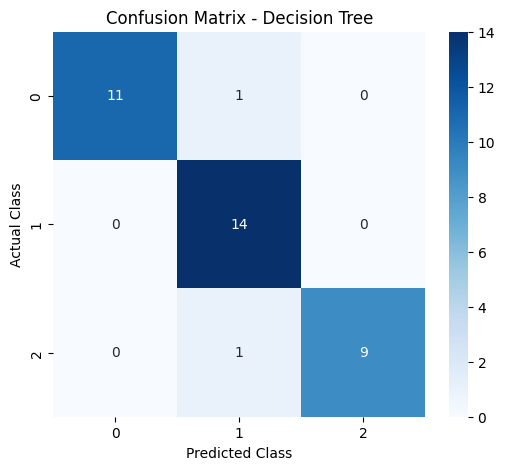

In [19]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Decision Tree")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

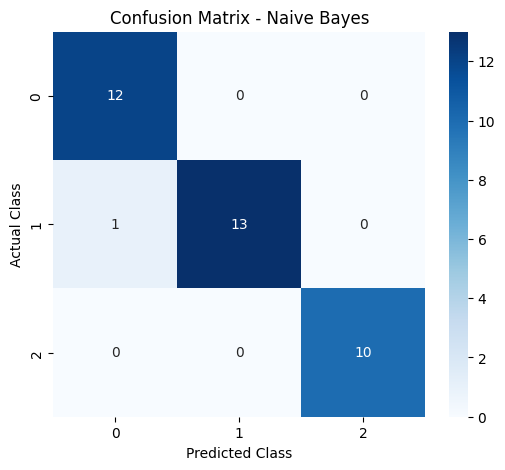

In [20]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Naive Bayes")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

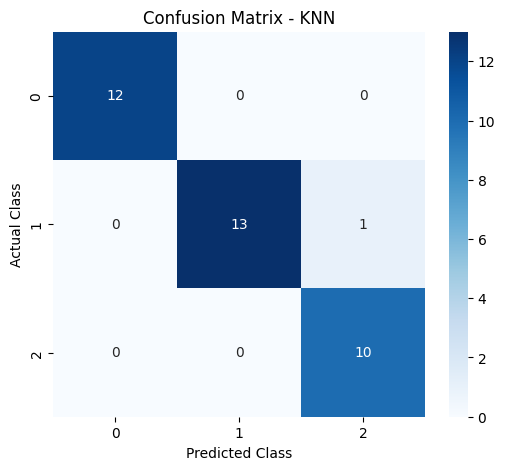

In [21]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - KNN")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

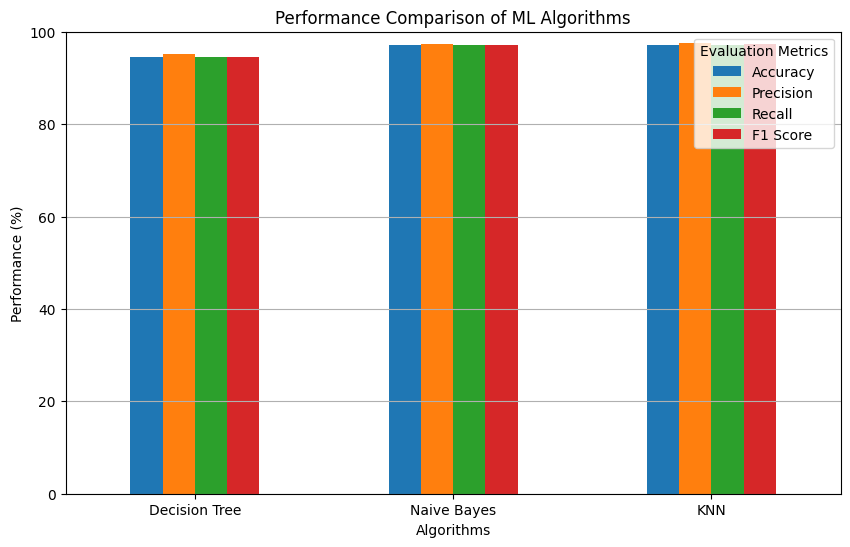

In [22]:
results_percentage.set_index(
    "Algorithm"
)[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Performance Comparison of ML Algorithms"
)

plt.xlabel("Algorithms")

plt.ylabel("Performance (%)")

plt.xticks(rotation=0)

plt.ylim(0, 100)

plt.legend(
    title="Evaluation Metrics"
)

plt.grid(
    axis="y"
)

plt.show()

In [23]:
best_index = results["F1 Score"].idxmax()

best_algorithm = results.loc[
    best_index,
    "Algorithm"
]

best_accuracy = results.loc[
    best_index,
    "Accuracy"
]

best_precision = results.loc[
    best_index,
    "Precision"
]

best_recall = results.loc[
    best_index,
    "Recall"
]

best_f1 = results.loc[
    best_index,
    "F1 Score"
]

In [24]:
print("\n")
print("==========FINAL RESULTS==========")

print(
    "\nBest Performing Algorithm:",
    best_algorithm
)

print(
    "Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(best_precision * 100, 2),
    "%"
)

print(
    "Recall:",
    round(best_recall * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(best_f1 * 100, 2),
    "%"
)

print("\n==========CONCLUSION==========")

print(
    f"\nAmong Decision Tree, Naive Bayes and KNN, "
    f"{best_algorithm} performed the best based on "
    f"the highest F1 Score."
)



==========FINAL RESULTS==========

Best Performing Algorithm: KNN
Accuracy: 97.22 %
Precision: 97.47 %
Recall: 97.22 %
F1 Score: 97.24 %

==========CONCLUSION==========

Among Decision Tree, Naive Bayes and KNN, KNN performed the best based on the highest F1 Score.
